# Gaussian Naive Bayes - Wine Dataset 

In [33]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_wine

In [34]:
wine = load_wine()
X = wine.data.astype(float)
y = wine.target.astype(int)
feature_names = wine.feature_names
target_names = wine.target_names

print('Features shape:', X.shape)
print('Target shape  :', y.shape)
print('Classes       :', list(target_names))
print('Class counts  :', {int(c): int((y == c).sum()) for c in np.unique(y)})

pd.DataFrame(X, columns=feature_names).head()

Features shape: (178, 13)
Target shape  : (178,)
Classes       : [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]
Class counts  : {0: 59, 1: 71, 2: 48}


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [35]:
def train_test_split_custom(X, y, test_size=0.25, random_state=42, shuffle=True):
    n = len(X)
    indices = np.arange(n)

    if shuffle:
        rng = np.random.default_rng(seed=random_state)
        rng.shuffle(indices)

    test_count = int(n * test_size)
    test_idx = indices[:test_count]
    train_idx = indices[test_count:]

    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]


class GaussianNaiveBayes:
    def __init__(self, epsilon=1e-9):
        self.epsilon = epsilon
        self.classes_ = None
        self.class_prior_ = {}
        self.mean_ = {}
        self.var_ = {}

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        n_samples = X.shape[0]

        for c in self.classes_:
            X_c = X[y == c]
            self.class_prior_[c] = X_c.shape[0] / n_samples
            self.mean_[c] = X_c.mean(axis=0)
            self.var_[c] = X_c.var(axis=0) + self.epsilon

    def _gaussian_log_likelihood(self, class_label, x):
        mean = self.mean_[class_label]
        var = self.var_[class_label]

        log_term = -0.5 * np.log(2.0 * np.pi * var)
        exp_term = -((x - mean) ** 2) / (2.0 * var)
        return np.sum(log_term + exp_term)

    def _joint_log_posterior(self, x):
        scores = {}
        for c in self.classes_:
            log_prior = np.log(self.class_prior_[c])
            log_likelihood = self._gaussian_log_likelihood(c, x)
            scores[c] = log_prior + log_likelihood
        return scores

    def predict(self, X):
        preds = []
        for x in X:
            scores = self._joint_log_posterior(x)
            preds.append(max(scores, key=scores.get))
        return np.array(preds, dtype=int)


def accuracy_score(y_true, y_pred):
    return float(np.mean(y_true == y_pred))

In [36]:
X_train, X_test, y_train, y_test = train_test_split_custom(
    X, y, test_size=0.25, random_state=42, shuffle=True
)

model = GaussianNaiveBayes(epsilon=1e-9)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print('Train size:', len(X_train))
print('Test size :', len(X_test))
print(f'Accuracy  : {acc * 100:.2f}%')

Train size: 134
Test size : 44
Accuracy  : 97.73%


In [37]:
n_show = min(10, len(X_test))
print('Index | Actual | Predicted')
for i in range(n_show):
    print(f'{i:>5} | {y_test[i]:>6} | {y_pred[i]:>9}')

Index | Actual | Predicted
    0 |      2 |         2
    1 |      1 |         1
    2 |      0 |         0
    3 |      2 |         2
    4 |      0 |         0
    5 |      0 |         0
    6 |      2 |         2
    7 |      1 |         1
    8 |      0 |         0
    9 |      2 |         2


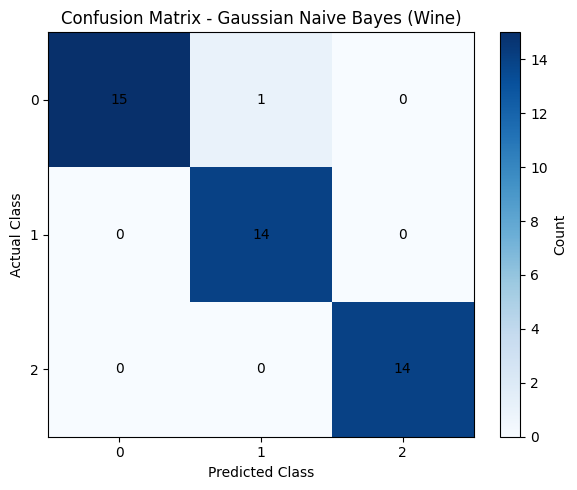

In [38]:
import matplotlib.pyplot as plt

class_names = [str(c) for c in sorted(np.unique(y))]
class_to_idx = {c: i for i, c in enumerate(sorted(np.unique(y)))}
cm = np.zeros((len(class_names), len(class_names)), dtype=int)

for t, p in zip(y_test, y_pred):
    cm[class_to_idx[t], class_to_idx[p]] += 1

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues', aspect='auto')

ax.set_title('Confusion Matrix - Gaussian Naive Bayes (Wine)')
ax.set_xlabel('Predicted Class')
ax.set_ylabel('Actual Class')
ax.set_xticks(range(len(class_names)))
ax.set_yticks(range(len(class_names)))
ax.set_xticklabels(class_names)
ax.set_yticklabels(class_names)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', color='black')

cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Count')

plt.tight_layout()
plt.show()